In [1]:
from collections import defaultdict
import json
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import seaborn as sns

In [2]:
# Load data
def load_data(path):
    data = []
    for root, dirs, files in os.walk(path):
        for filename in files:
            if filename.endswith(".json"):
                file_path = os.path.join(root, filename)
                try:
                    with open(file_path, "r") as f:
                        entry = json.load(f)
                        data.append(entry)
                except json.JSONDecodeError as e:
                    print(f"Skipped invalid JSON: {file_path} ({e})")
                    
    print(f"Loaded {len(data)} valid JSON result files from '{folder_path}' and its subfolders.")
    return data

folder_path = "../results/base_cues_5/"
data_cues_5 = load_data(folder_path)
folder_path = "../results/base_cues_10/"
data_cues_10 = load_data(folder_path)
folder_path = "../results/base_none_5/"
data_none_5 = load_data(folder_path)
folder_path = "../results/base_none_10/"
data_none_10 = load_data(folder_path)

data_cues = data_cues_5 + data_cues_10
data_none = data_none_5 + data_none_10
data_5 = data_cues_5 + data_none_5
data_10 = data_cues_10 + data_none_10

Loaded 3772 valid JSON result files from '../results/base_cues_5/' and its subfolders.
Loaded 6697 valid JSON result files from '../results/base_cues_10/' and its subfolders.
Loaded 4218 valid JSON result files from '../results/base_none_5/' and its subfolders.
Loaded 4151 valid JSON result files from '../results/base_none_10/' and its subfolders.


In [3]:
model_names = ["claude", "deepseek", "gemini", "gpt", "llama", "mistral", "qwen"]
pretty_names = {
    "gpt": "GPT",
    "llama": "LLaMA",
    "mistral": "Mistral",
    "claude": "Claude",
    "qwen": "Qwen",
    "gemini": "Gemini",
    "deepseek": "DeepSeek"
}

def transform_data(data):
    correct_counts = {a: {b: 0 for b in model_names} for a in model_names}
    total_counts = {a: {b: 0 for b in model_names} for a in model_names}
    
    for entry in data:
        model_0 = entry["model_general_name_0"].lower()
        model_1 = entry["model_general_name_1"].lower()
        guess_0 = entry["agent_0_guess"].lower()
        guess_1 = entry["agent_1_guess"].lower()
    
        if model_0 in model_names and model_1 in model_names:
            total_counts[model_0][model_1] += 1
            if guess_0 == model_1:
                correct_counts[model_0][model_1] += 1

        if model_1 in model_names and model_0 in model_names:
            total_counts[model_1][model_0] += 1
            if guess_1 == model_0:
                correct_counts[model_1][model_0] += 1
    
    accuracy_matrix = {
        a: {
            b: (correct_counts[a][b] / total_counts[a][b]) if total_counts[a][b] > 0 else None
            for b in model_names
        }
        for a in model_names
    }
    
    df_accuracy = pd.DataFrame(accuracy_matrix).T

    return df_accuracy

df_5_c = transform_data(data_cues_5)
df_10_c = transform_data(data_cues_10)
df_5_n = transform_data(data_none_5)
df_10_n = transform_data(data_none_10)

df_c = transform_data(data_cues)
df_n = transform_data(data_none)
df_5 = transform_data(data_5)
df_10 = transform_data(data_10)

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib

# Use serif font
matplotlib.rcParams.update({"font.family": "serif"})

def show_plot(df, savename, rangify=True):
    # Generate heatmap
    plt.figure(figsize=(14, 12))

    if rangify:
        ax = sns.heatmap(
            df.astype(float),
            annot=True,
            fmt=".2f",
            cmap='YlGnBu',
            linewidths=0.5,
            square=True,
            vmin=0,
            vmax=1,
            annot_kws={"fontsize": 22}
        )
    else:
        ax = sns.heatmap(
            df.astype(float),
            annot=True,
            fmt=".2f",
            cmap='YlGnBu',
            linewidths=0.5,
            square=True,
            vmin=-1,
            vmax=1,
            annot_kws={"fontsize": 22}
        )
    
    # Titles and axis labels
    plt.title("LLM Identifier Game: Accuracy of Model Guesses", fontsize=30, pad=30)
    plt.xlabel("Target Model", fontsize=28, labelpad=25)
    plt.ylabel("Guesser Model", fontsize=28, labelpad=25)
    
    # Apply pretty labels to ticks
    x_labels = [pretty_names.get(label.get_text(), label.get_text()) for label in ax.get_xticklabels()]
    y_labels = [pretty_names.get(label.get_text(), label.get_text()) for label in ax.get_yticklabels()]
    
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=28)
    ax.set_yticklabels(y_labels, rotation=0, fontsize=28)
    
    # Colorbar font size
    cbar = ax.collections[0].colorbar
    cbar.ax.tick_params(labelsize=28)
    
    # Save high-res output
    plt.tight_layout()
    plt.savefig(f"figures_and_files/guessingaccuracy_{savename}.eps", dpi=300, bbox_inches='tight')
    plt.show()

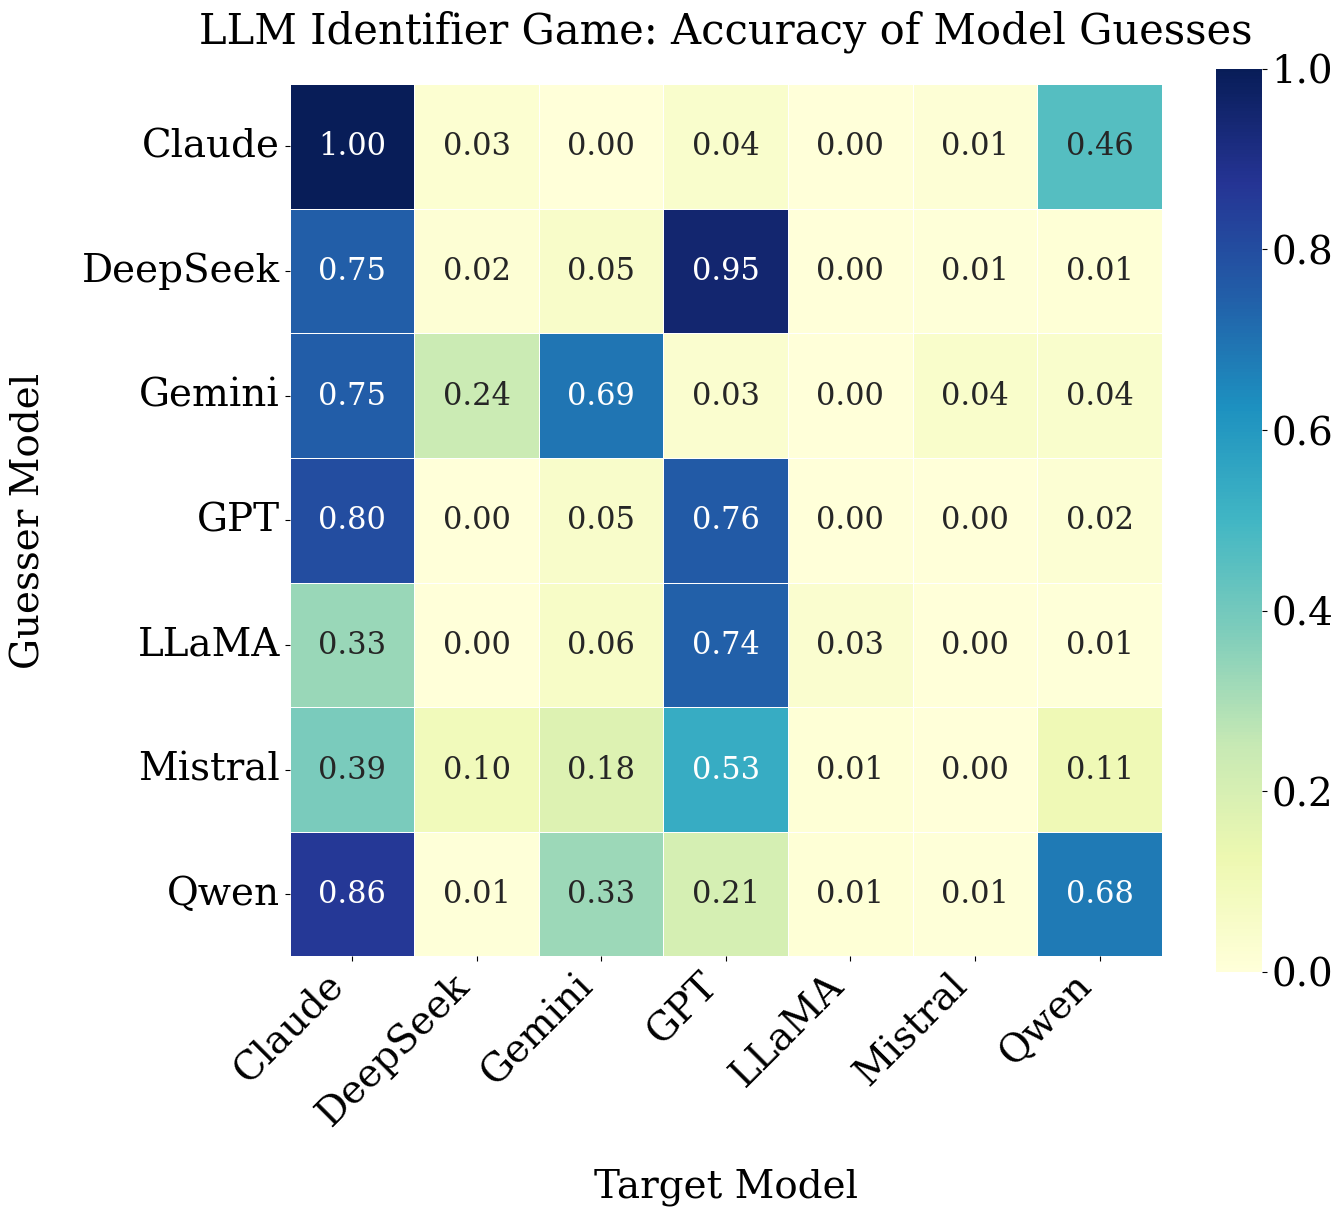

In [5]:
show_plot(df_5_c, "c5")

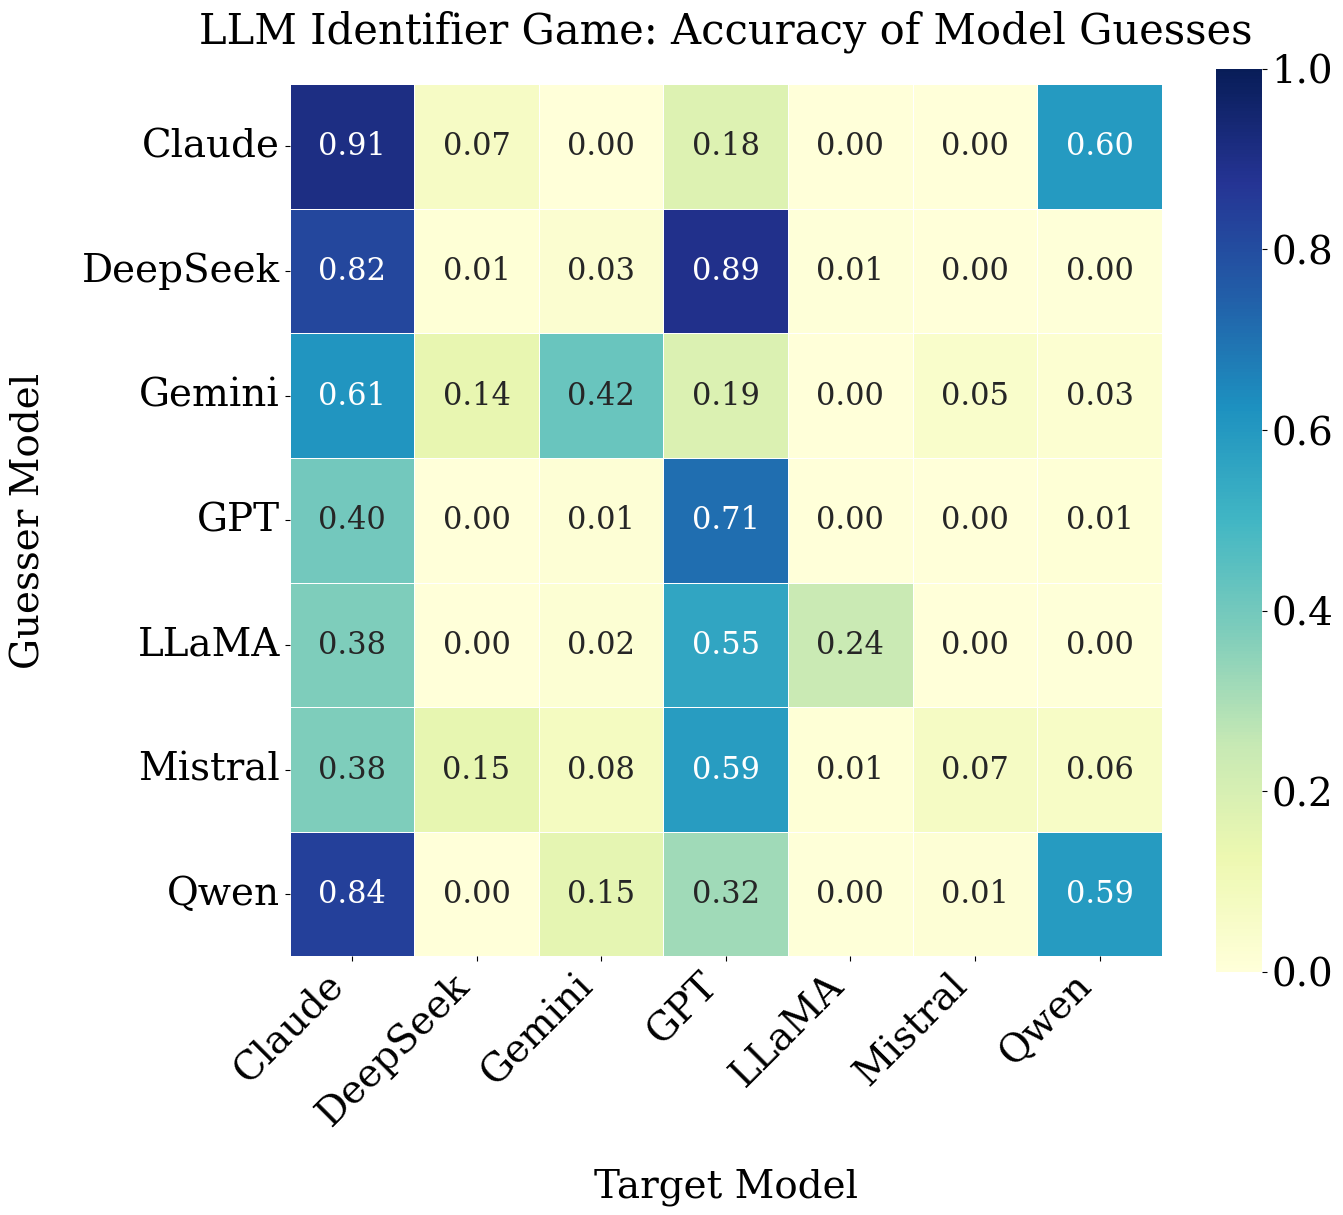

In [6]:
show_plot(df_10_c, "c10")

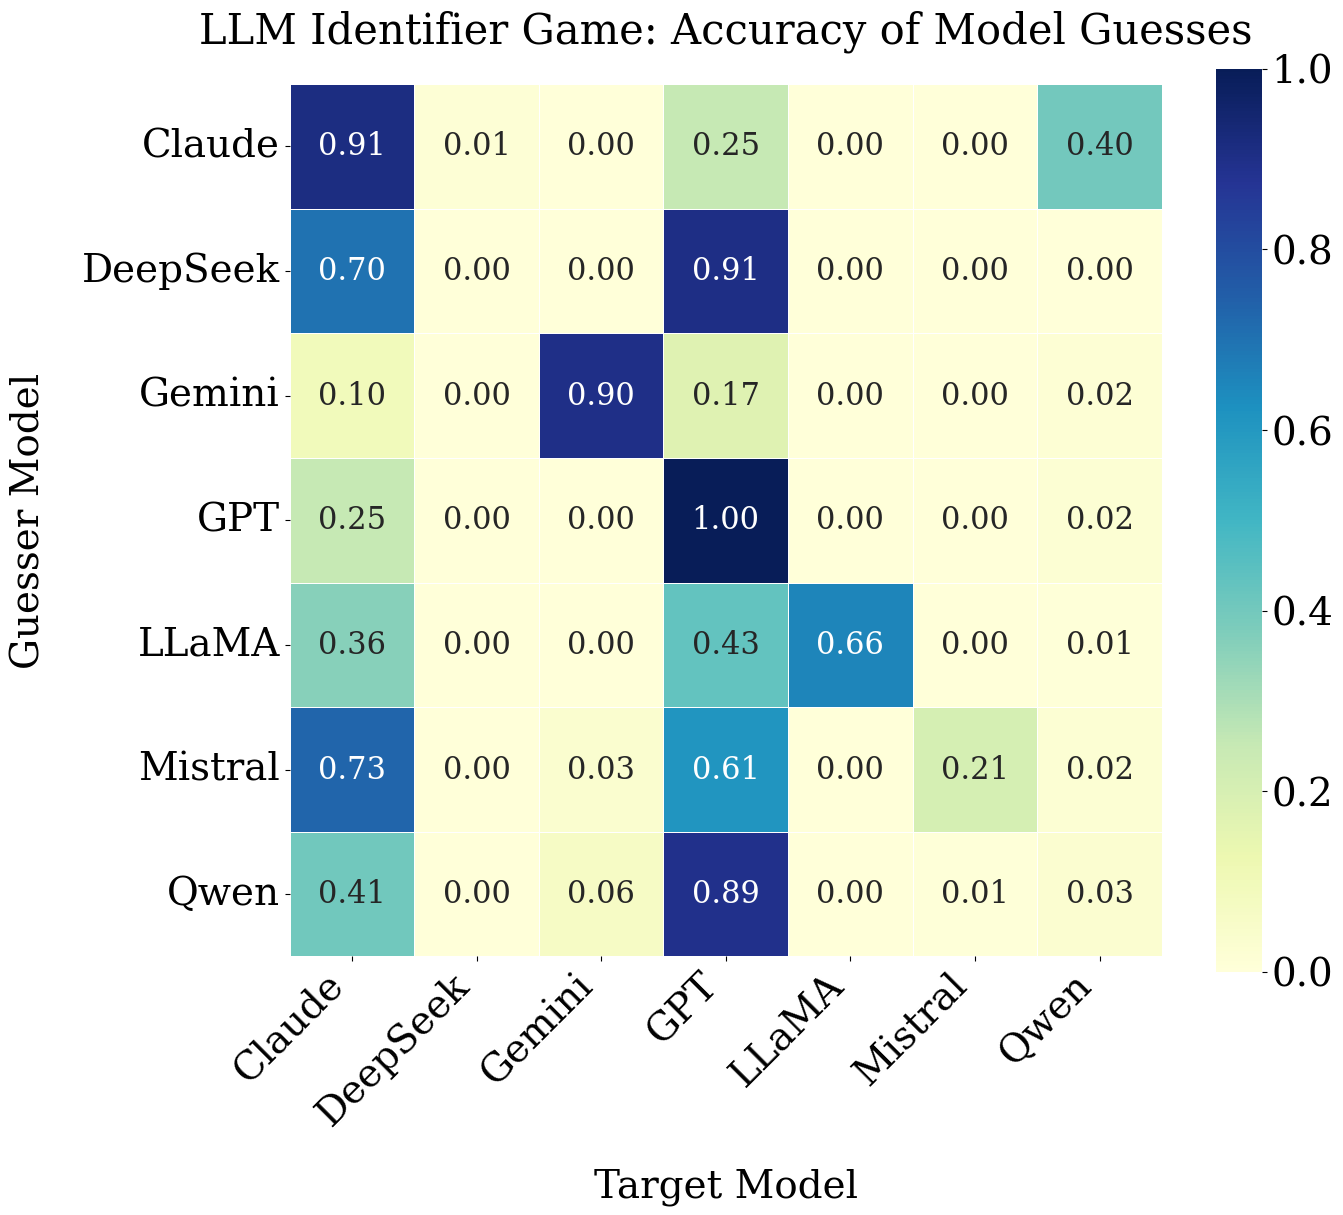

In [7]:
show_plot(df_5_n, "n5")

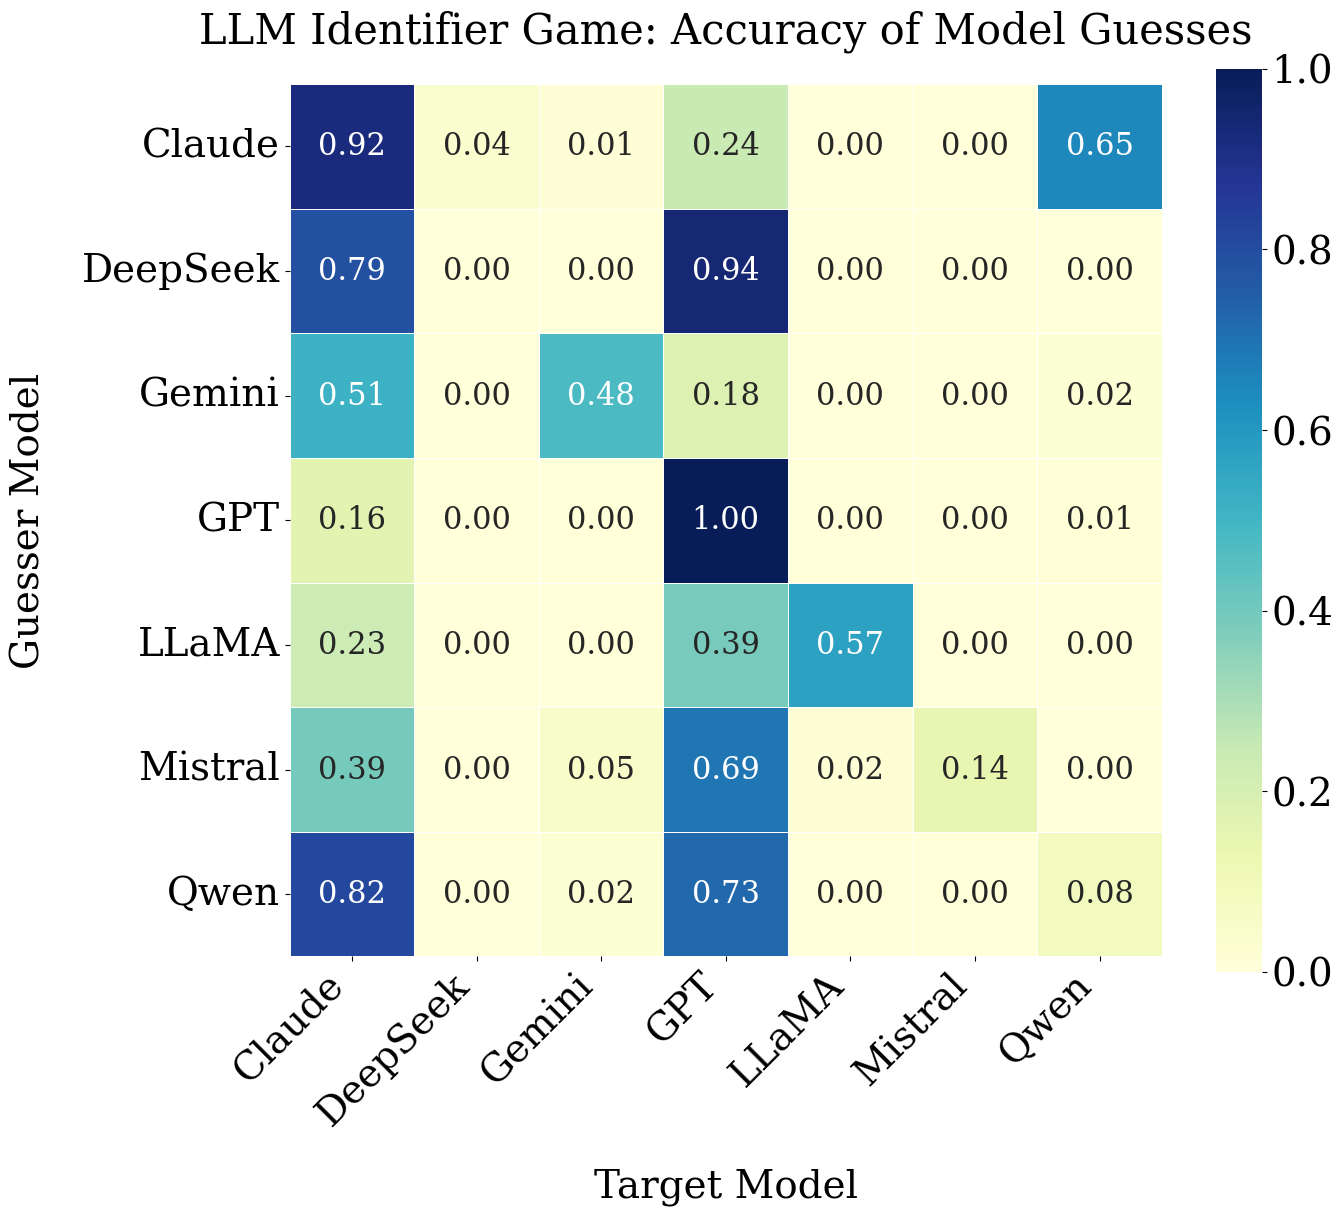

In [8]:
show_plot(df_10_n, "n10")

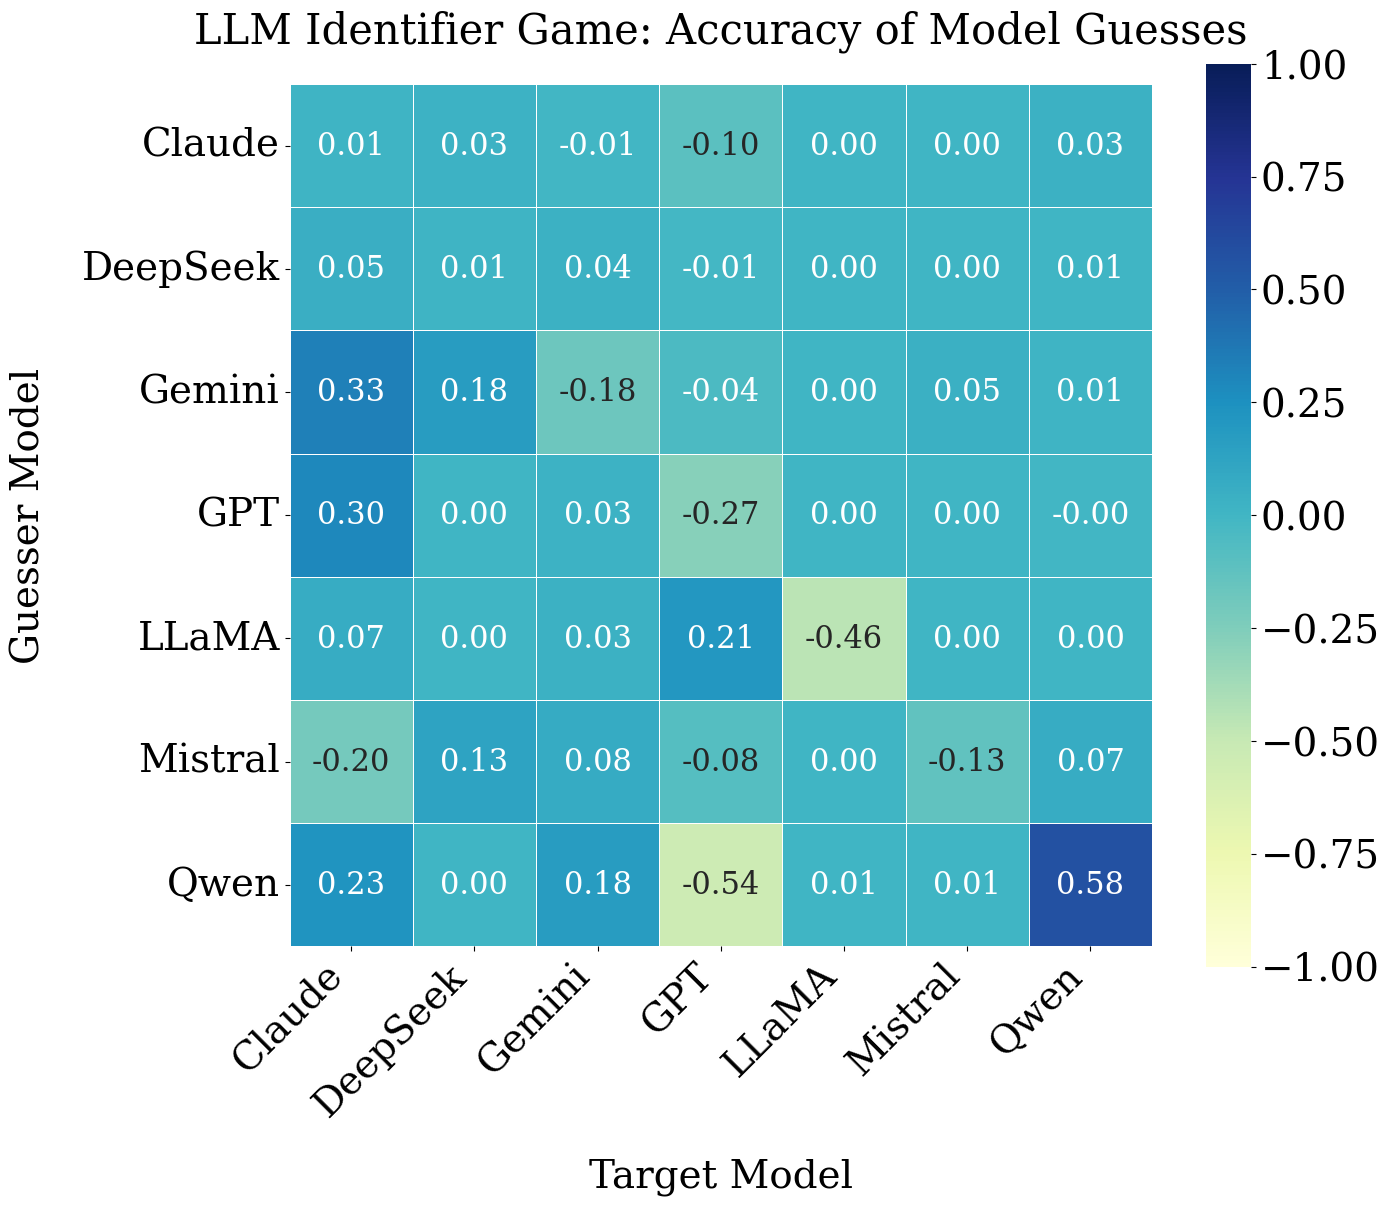

In [9]:
show_plot(df_c - df_n, "cues_minus_none", rangify=False)

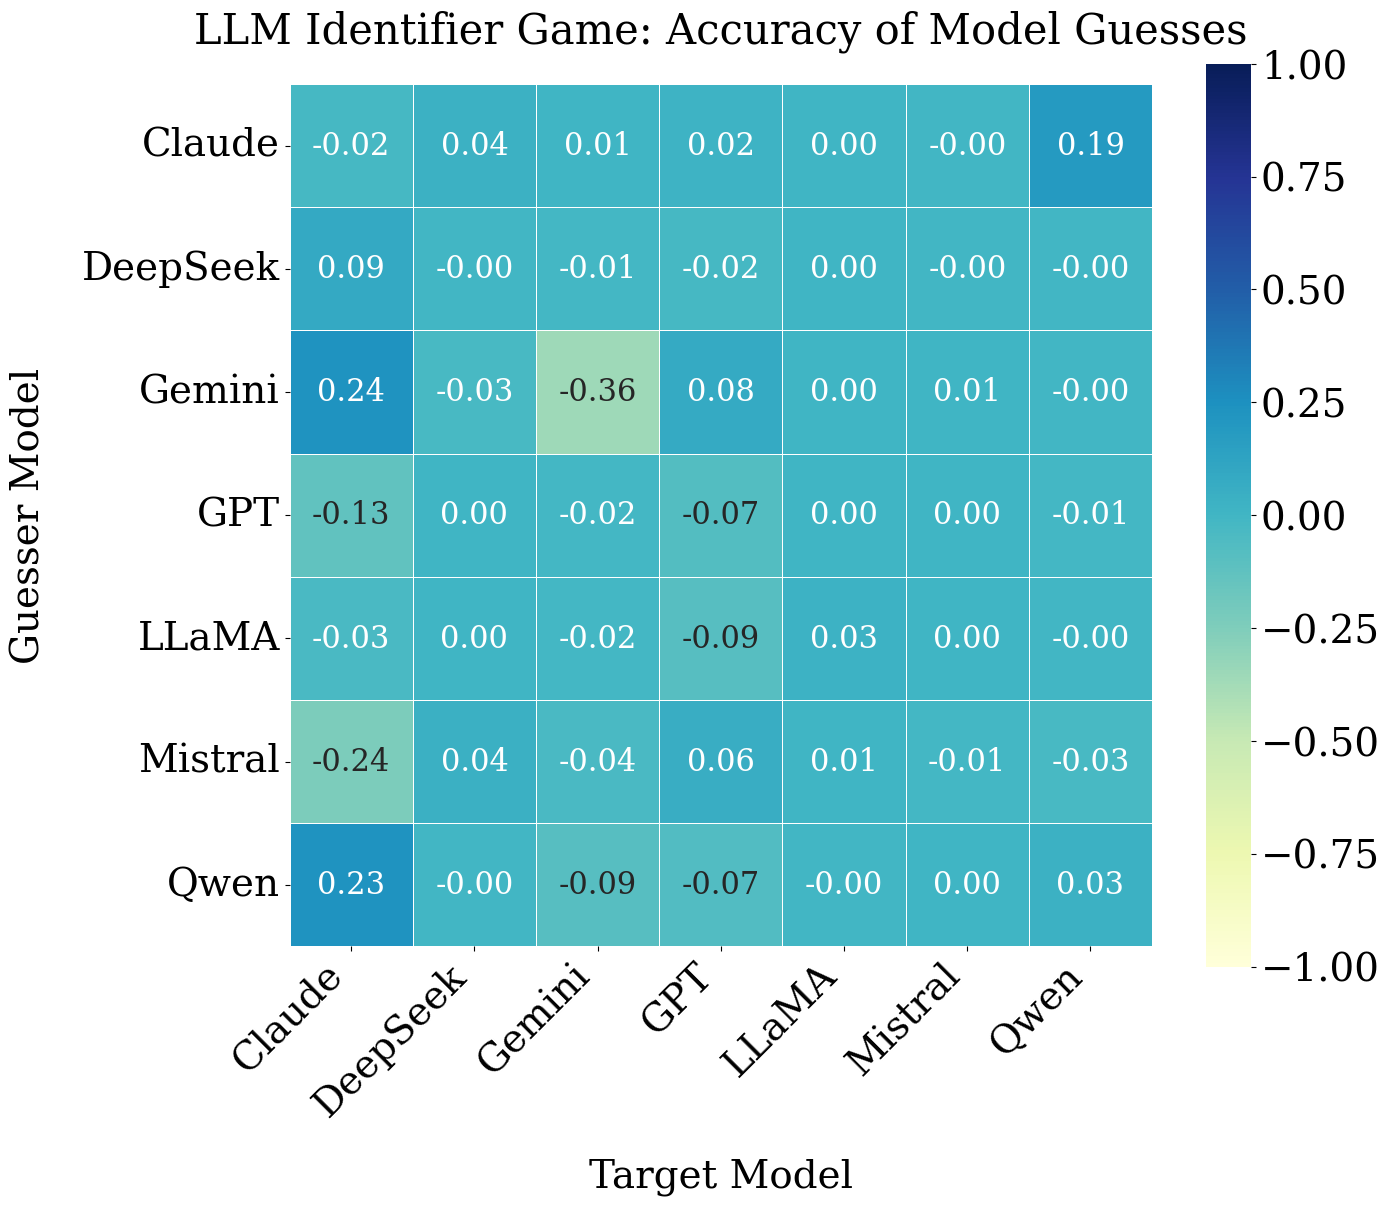

In [10]:
show_plot(df_10 - df_5, "ten_minus_five", rangify=False)